# Notebook 02 — Strategy cards: choosing *how* to pick a batch

In Notebook 01 you ran one round with a single acquisition function (qLogNEHVI).
In the competition you will mix and match acquisition functions round by round.
We package each acquisition as a **strategy card**, and a round's choice as a
**batch plan** — a dict that says how many of the `BATCH_SIZE` slots each card
fills:

```python
{"nehvi": 4}                 # all four slots from qLogNEHVI
{"nehvi": 2, "parego": 2}    # two from each
{"nehvi": 3, "random": 1}    # spend one slot on exploration
```

The cards:

- **`nehvi`** — expands the Pareto front where hypervolume gain looks largest.
- **`parego`** — samples a *random* trade-off preference each pick, so it spreads
  across the front.
- **`scalarized_0.8_0.2` / `scalarized_0.2_0.8`** — commit to a *fixed*
  preference (favor objective 1, or objective 2).
- **`random`** — a baseline: pick unmeasured antibodies at random.
- **`uncertainty`** — spend the budget where the model is least sure.

This notebook is still **guided practice**: we run *one round from the same
starting point* with several plans and compare what each one picks.

## Setup

Same starting point as Notebook 01: seed everything, load the pool, oracle, and
shared initial design, and fit the surrogate **once**. Every plan below starts
from this identical observed set, so any difference comes purely from the *card
choice*.

In [1]:
import matplotlib.pyplot as plt
import torch

from mobo_lab import config, data, metrics, plotting, seed, strategies
from mobo_lab.acquisitions import make_sampler
from mobo_lab.models import fit_surrogate_model
from mobo_lab.oracle import AntibodyOracle
from mobo_lab.pool import VHSequencePool

seed.set_all_seeds(config.SEED)
BATCH_SIZE = config.BATCH_SIZE
REF_POINT = config.REF_POINT

pool = VHSequencePool.from_files()
oracle = AntibodyOracle.from_files(allow_true=False)
observed_ids = data.load_initial_ids()
train_X = pool.X[observed_ids]
train_Y = oracle.evaluate(observed_ids)
model = fit_surrogate_model(train_X, train_Y)

hv_before = metrics.compute_hypervolume(train_Y, REF_POINT)
print(f"starting from {len(observed_ids)} measured antibodies; HV = {hv_before:.4f}")

starting from 12 measured antibodies; HV = 0.4209


## The batch-plan object

A plan is just a dict. The one rule: the slot counts must add up to `BATCH_SIZE`.
`validate_batch_plan` gives a friendly error if they don't — try editing the
numbers below to see it.

In [2]:
batch_plan = {"nehvi": 2, "parego": 2}
strategies.validate_batch_plan(batch_plan)  # raises ValueError if sum != BATCH_SIZE
print("valid plan:", batch_plan)

valid plan: {'nehvi': 2, 'parego': 2}


## Run one round from a plan

`propose_batch_from_plan` fills the batch card by card (sequential greedy, each
pick aware of the ones before it), then we measure the chosen antibodies and see
how the hypervolume moved. This is exactly the Notebook 01 round, but driven by a
plan instead of a single hard-coded acquisition.

In [3]:
sampler = make_sampler(seed=config.SEED)
bounds = config.latent_bounds()

ids = strategies.propose_batch_from_plan(
    batch_plan, model, pool, observed_ids, train_X, train_Y,
    ref_point=REF_POINT, bounds=bounds, sampler=sampler,
)
new_Y = oracle.evaluate(ids)
hv_after = metrics.compute_hypervolume(torch.cat([train_Y, new_Y]), REF_POINT)

print("selected IDs:", ids)
print(f"HV: {hv_before:.4f} -> {hv_after:.4f}  (+{hv_after - hv_before:.4f})")

selected IDs: [1365, 921, 1855, 1839]
HV: 0.4209 -> 0.5781  (+0.1572)


## Compare the cards

Now the main exercise: run several plans, **each from the same starting state**,
and tabulate what they do. For each plan we record the selected IDs, the
hypervolume improvement, and an *objective spread* — the mean pairwise distance
between the selected points in objective space. A small spread means the plan
concentrated its picks in one trade-off region; a large spread means it fanned
out.

In [4]:
plans = {
    "nehvi": {"nehvi": 4},
    "parego": {"parego": 4},
    "scalarized_0.8_0.2": {"scalarized_0.8_0.2": 4},
    "scalarized_0.2_0.8": {"scalarized_0.2_0.8": 4},
    "nehvi+parego": {"nehvi": 2, "parego": 2},
    "nehvi+random": {"nehvi": 3, "random": 1},
}

results = {}
print(f"{'plan':<20}{'HV gain':>9}{'obj spread':>12}   selected IDs")
print("-" * 70)
for label, plan in plans.items():
    plan_ids = strategies.propose_batch_from_plan(
        plan, model, pool, observed_ids, train_X, train_Y,
        ref_point=REF_POINT, bounds=bounds, sampler=make_sampler(seed=config.SEED),
    )
    plan_Y = oracle.evaluate(plan_ids)
    hv = metrics.compute_hypervolume(torch.cat([train_Y, plan_Y]), REF_POINT)
    spread = metrics.compute_embedding_diversity(plan_Y)  # mean pairwise dist in objective space

    # invariants every plan must satisfy
    assert len(plan_ids) == BATCH_SIZE and len(set(plan_ids)) == BATCH_SIZE
    assert not (set(plan_ids) & set(observed_ids))
    assert hv >= hv_before - 1e-9

    results[label] = {"ids": plan_ids, "Y": plan_Y, "hv_gain": hv - hv_before, "spread": spread}
    print(f"{label:<20}{hv - hv_before:>9.4f}{spread:>12.4f}   {plan_ids}")

plan                  HV gain  obj spread   selected IDs
----------------------------------------------------------------------


nehvi                  0.1515      0.2598   [1365, 921, 1844, 581]
parego                 0.2297      0.1685   [1365, 1210, 1069, 1757]
scalarized_0.8_0.2     0.1445      0.1640   [1855, 1839, 1210, 1037]


scalarized_0.2_0.8     0.1678      0.1207   [1855, 1210, 1839, 1505]


nehvi+parego           0.1515      0.1104   [1365, 921, 1855, 1210]


nehvi+random           0.4121      0.2381   [1855, 1371, 431, 31]


## Where did each plan look?

Each panel shows the existing measurements (gray) and one plan's newly selected
antibodies (colored), in objective space. Notice how the **fixed** scalarizations
pull toward one side (favoring objective 1 or objective 2), while `nehvi` and
`parego` spread their picks along the frontier.

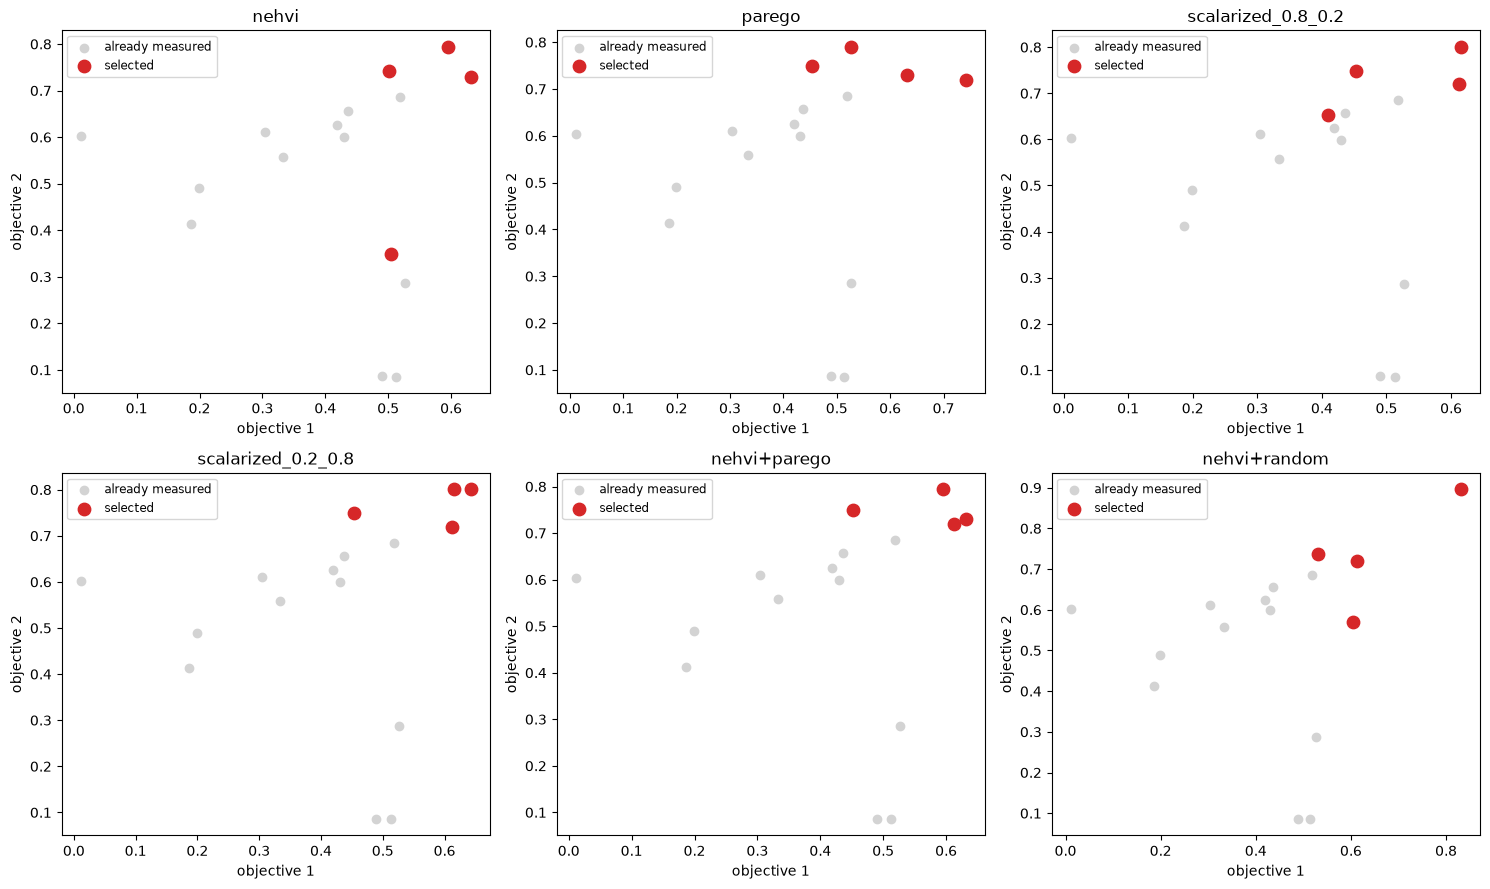

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, res) in zip(axes.flat, results.items()):
    ax.scatter(train_Y[:, 0], train_Y[:, 1], color="lightgray", label="already measured")
    ax.scatter(res["Y"][:, 0], res["Y"][:, 1], color="tab:red", s=80, label="selected")
    ax.set_title(label)
    ax.set_xlabel("objective 1")
    ax.set_ylabel("objective 2")
    ax.legend(loc="best", fontsize="small")
fig.tight_layout();

## Which plan grew the front most this round?

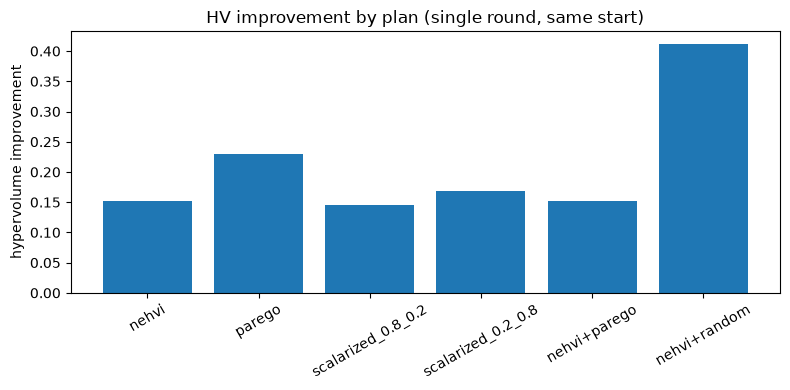

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(results)
gains = [results[k]["hv_gain"] for k in labels]
ax.bar(labels, gains, color="tab:blue")
ax.set_ylabel("hypervolume improvement")
ax.set_title("HV improvement by plan (single round, same start)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout();

## Discuss

Talk through these with your group — there is no single right answer, and the
picture changes over multiple rounds:

1. **Which plan grew hypervolume most this round?** Is the winner of a *single*
   round necessarily the best strategy for a *six-round* campaign?
2. **Which plan concentrated** its picks (small objective spread), and which fanned
   out? Look at `scalarized_0.8_0.2` vs `nehvi`/`parego`.
3. A fixed scalarization can win *early* by exploiting one corner, then stall once
   that corner is saturated. When might spending a slot on `random` or
   `uncertainty` **now** pay off in *later* rounds?
4. In the competition you choose a *sequence* of plans, one per round. Sketch a
   plan-per-round strategy for your team and note *why*.

Next up: the competition, where these choices compound over six rounds under a
fixed budget.